## Explore MPAS-A static data Globally

Try **MPAS-Viewer**, which reads remote MPAS datasets from **THREDDS servers** and enables interactive visualization of a **Quasi-unifrom coarse mesh (480 km)**. This example focuses on showing what a **mesh covering the globe** looks like..

Open the notebook in **Google Colab** and start exploring the data immediately - **No installation on your local machine or data download is required.**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhbravo/mpasviewer/blob/main/examples/16_remote_static_global.ipynb)

### Data Source

For a more detailed description of the data and its accessibility, you are advised to visit Geoscience Data Exchange (GDEX): 

[![GDEX Dataset](https://img.shields.io/badge/GDEX-Dataset-blue)](https://gdex.ucar.edu/datasets/)


### THREDDS Data Service

Remote access is provided through the GDEX THREDDS server: 

[![THREDDS Catalog](https://img.shields.io/badge/THREDDS-Catalog-green)](https://tds.gdex.ucar.edu/thredds/catalog/files/d010129/catalog.html)

### Step 0 
For Google Colab users, uncomment and run the following cell to install the required packages. If your environment is already set up, you can skip this step and proceed to Step 1.

In [18]:
# %%capture
# !pip install git+https://github.com/jhbravo/earthcmap.git

# !pip install git+https://github.com/jhbravo/mpasviewer.git

# !pip install cartopy netcdf4 s3fs zarr rasterio rioxarray

# !pip uninstall numpy -y
# !pip install "numpy<2.0.0"

### Step 1
Importe the required libraries

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
# from datetime import datetime

In [33]:
mpasd = scvtmesh(grid_file = 'https://tds.gdex.ucar.edu/thredds/dodsC/files/d010129/480km/x1.2562.static.nc')

In [34]:
mpasd.dataset()
# mpasd.dataset(load_variables=['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',])

Loaded grid_file dataset: https://tds.gdex.ucar.edu/thredds/dodsC/files/d010129/480km/x1.2562.static.nc


In [35]:
dta = mpasd.load()

In [8]:
from earthcmap import escmap

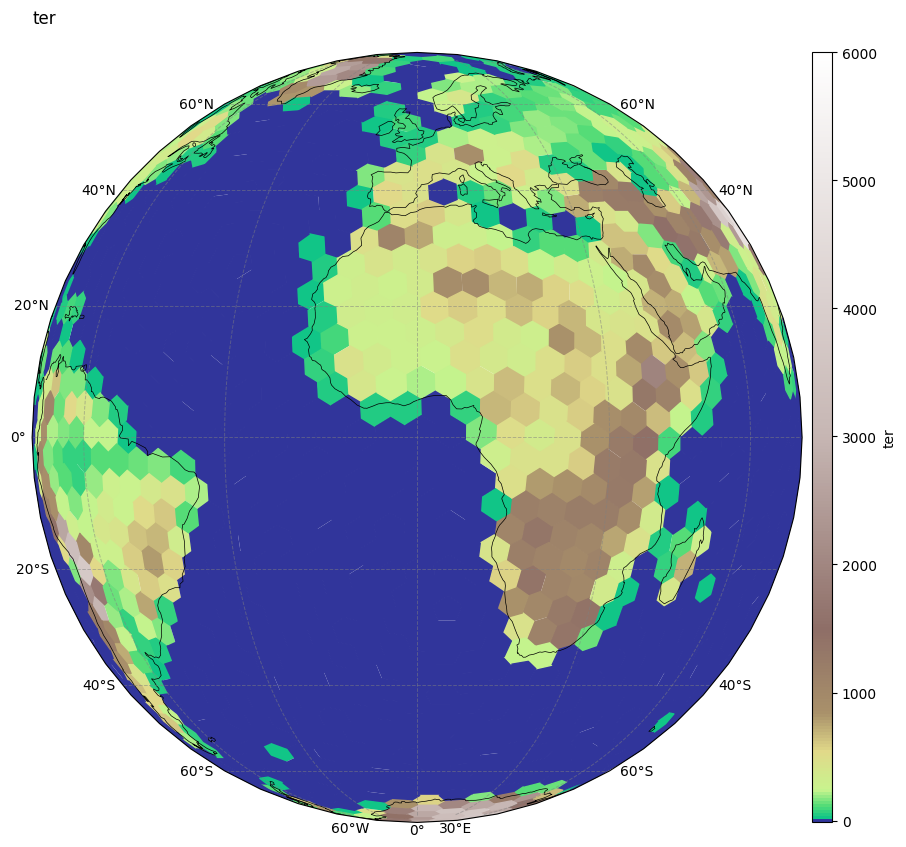

In [9]:
cmap, norm = escmap("terrain")
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm, figsize = (10, 10))

In [11]:
from ipywidgets import interact, Dropdown, IntSlider, SelectionSlider, FloatSlider
from IPython.display import display, clear_output

In [37]:
lat_slider = FloatSlider(
    value=40.7,
    min=-90,
    max=90,
    step=0.1,
    description='Latitude:',
    continuous_update=True
)

lon_slider = FloatSlider(
    value=-74.0,
    min=-180,
    max=180,
    step=0.1,
    description='Longitude:',
    continuous_update=True
)

cmps = {'ter':"terrain", 'ivgtyp':"lalc", 'isltyp':"soil_comet"}
variable_dropdown = Dropdown(options=cmps.keys(), description='Variable:')

In [38]:
def show_location(variable, lat, lon):
    cmap, norm = escmap(cmps[variable])
    mpasd.show(dta, var_name = variable, cmap = cmap, norm = norm, crs = ccrs.Orthographic(central_longitude=lon, central_latitude=lat), figsize = (8, 8))

In [39]:
%%time
# # Create the interactive plot
interact(show_location, variable=variable_dropdown, lat=lat_slider, lon=lon_slider)

interactive(children=(Dropdown(description='Variable:', options=('ter', 'ivgtyp', 'isltyp'), value='ter'), Flo…

CPU times: user 1.44 s, sys: 6.74 ms, total: 1.44 s
Wall time: 1.44 s


<function __main__.show_location(variable, lat, lon)>